# Guwahati Economic Indicators Analysis
**Peyali Chakraborty**

I have been living in Guwahati since my graduation and got curious about how the city has been changing economically — cost of living, employment trends, which sectors are growing. So I decided to dig into the numbers myself.

This notebook analyses economic indicators for Guwahati from 2021 to 2026 using Python and SQLite.


## Step 1: Import Libraries

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Create the Database

I created a SQLite database with two tables:
- **cost_of_living** — monthly expenses (rent, groceries, transport) from 2021 to 2026
- **employment** — workforce distribution across sectors for the same period

In [2]:
conn = sqlite3.connect("guwahati_economy.db")
cursor = conn.cursor()

# Table 1: Cost of Living
cursor.execute("DROP TABLE IF EXISTS cost_of_living")
cursor.execute("""
CREATE TABLE cost_of_living (
    year        INTEGER,
    category    TEXT,
    amount_inr  REAL
)
""")

col_data = [
    (2021, "Rent (1BHK)",          9500),
    (2022, "Rent (1BHK)",         10800),
    (2023, "Rent (1BHK)",         12500),
    (2024, "Rent (1BHK)",         13800),
    (2025, "Rent (1BHK)",         15200),
    (2026, "Rent (1BHK)",         16500),

    (2021, "Monthly Groceries",    3900),
    (2022, "Monthly Groceries",    4300),
    (2023, "Monthly Groceries",    4700),
    (2024, "Monthly Groceries",    5100),
    (2025, "Monthly Groceries",    5500),
    (2026, "Monthly Groceries",    5900),

    (2021, "Transport (monthly)",  1250),
    (2022, "Transport (monthly)",  1500),
    (2023, "Transport (monthly)",  1700),
    (2024, "Transport (monthly)",  1900),
    (2025, "Transport (monthly)",  2100),
    (2026, "Transport (monthly)",  2300),
]
cursor.executemany("INSERT INTO cost_of_living VALUES (?, ?, ?)", col_data)

# Table 2: Employment
cursor.execute("DROP TABLE IF EXISTS employment")
cursor.execute("""
CREATE TABLE employment (
    year          INTEGER,
    sector        TEXT,
    workforce_pct REAL
)
""")

emp_data = [
    (2021, "Government & Public",  25.5), (2022, "Government & Public",  24.0),
    (2023, "Government & Public",  23.0), (2024, "Government & Public",  22.0),
    (2025, "Government & Public",  21.0), (2026, "Government & Public",  20.0),

    (2021, "Trade & Commerce",     22.5), (2022, "Trade & Commerce",     24.0),
    (2023, "Trade & Commerce",     25.5), (2024, "Trade & Commerce",     26.0),
    (2025, "Trade & Commerce",     26.5), (2026, "Trade & Commerce",     27.0),

    (2021, "IT & Services",        12.0), (2022, "IT & Services",        14.5),
    (2023, "IT & Services",        17.0), (2024, "IT & Services",        19.0),
    (2025, "IT & Services",        21.0), (2026, "IT & Services",        23.0),

    (2021, "Construction",         16.5), (2022, "Construction",         15.5),
    (2023, "Construction",         15.0), (2024, "Construction",         14.5),
    (2025, "Construction",         14.0), (2026, "Construction",         13.5),

    (2021, "Agriculture & Others", 23.5), (2022, "Agriculture & Others", 22.0),
    (2023, "Agriculture & Others", 19.5), (2024, "Agriculture & Others", 18.5),
    (2025, "Agriculture & Others", 17.5), (2026, "Agriculture & Others", 16.5),
]
cursor.executemany("INSERT INTO employment VALUES (?, ?, ?)", emp_data)
conn.commit()

print("Database created and both tables populated!")

Database created and both tables populated!


## Step 3: SQL Queries

Now I'll run SQL queries to extract insights from the data.

In [3]:
# Query 1: Total monthly cost of living per year
q1 = pd.read_sql_query("""
    SELECT year, ROUND(SUM(amount_inr), 2) AS total_monthly_cost
    FROM cost_of_living
    GROUP BY year
    ORDER BY year
""", conn)

print("Total Monthly Cost of Living (INR):")
print(q1.to_string(index=False))

Total Monthly Cost of Living (INR):
 year  total_monthly_cost
 2021             14650.0
 2022             16600.0
 2023             18900.0
 2024             20800.0
 2025             22800.0
 2026             24700.0


In [4]:
# Query 2: Rent trend over the years
q2 = pd.read_sql_query("""
    SELECT year, amount_inr AS rent_inr
    FROM cost_of_living
    WHERE category = 'Rent (1BHK)'
    ORDER BY year
""", conn)

print("Rent Trend (INR/month):")
print(q2.to_string(index=False))

Rent Trend (INR/month):
 year  rent_inr
 2021    9500.0
 2022   10800.0
 2023   12500.0
 2024   13800.0
 2025   15200.0
 2026   16500.0


In [5]:
# Query 3: IT sector workforce growth
q3 = pd.read_sql_query("""
    SELECT year, workforce_pct AS it_workforce_pct
    FROM employment
    WHERE sector = 'IT & Services'
    ORDER BY year
""", conn)

print("IT & Services Workforce Share (%):")
print(q3.to_string(index=False))

IT & Services Workforce Share (%):
 year  it_workforce_pct
 2021              12.0
 2022              14.5
 2023              17.0
 2024              19.0
 2025              21.0
 2026              23.0


In [6]:
# Query 4: Which sector dominated each year?
q4 = pd.read_sql_query("""
    SELECT year, sector, workforce_pct
    FROM employment e1
    WHERE workforce_pct = (
        SELECT MAX(workforce_pct)
        FROM employment e2
        WHERE e2.year = e1.year
    )
    ORDER BY year
""", conn)

print("Dominant Sector per Year:")
print(q4.to_string(index=False))

Dominant Sector per Year:
 year              sector  workforce_pct
 2021 Government & Public           25.5
 2022 Government & Public           24.0
 2022    Trade & Commerce           24.0
 2023    Trade & Commerce           25.5
 2024    Trade & Commerce           26.0
 2025    Trade & Commerce           26.5
 2026    Trade & Commerce           27.0


In [7]:
# Query 5: Average cost — 2021-2023 vs 2024-2026
q5 = pd.read_sql_query("""
    SELECT
        CASE WHEN year <= 2023 THEN '2021-2023' ELSE '2024-2026' END AS period,
        category,
        ROUND(AVG(amount_inr), 0) AS avg_cost_inr
    FROM cost_of_living
    GROUP BY period, category
    ORDER BY category, period
""", conn)

print("Average Cost — 2021-2023 vs 2024-2026:")
print(q5.to_string(index=False))

Average Cost — 2021-2023 vs 2024-2026:
   period            category  avg_cost_inr
2021-2023   Monthly Groceries        4300.0
2024-2026   Monthly Groceries        5500.0
2021-2023         Rent (1BHK)       10933.0
2024-2026         Rent (1BHK)       15167.0
2021-2023 Transport (monthly)        1483.0
2024-2026 Transport (monthly)        2100.0


## Step 4: Visualisations

Plotting the trends to make the findings easier to understand.

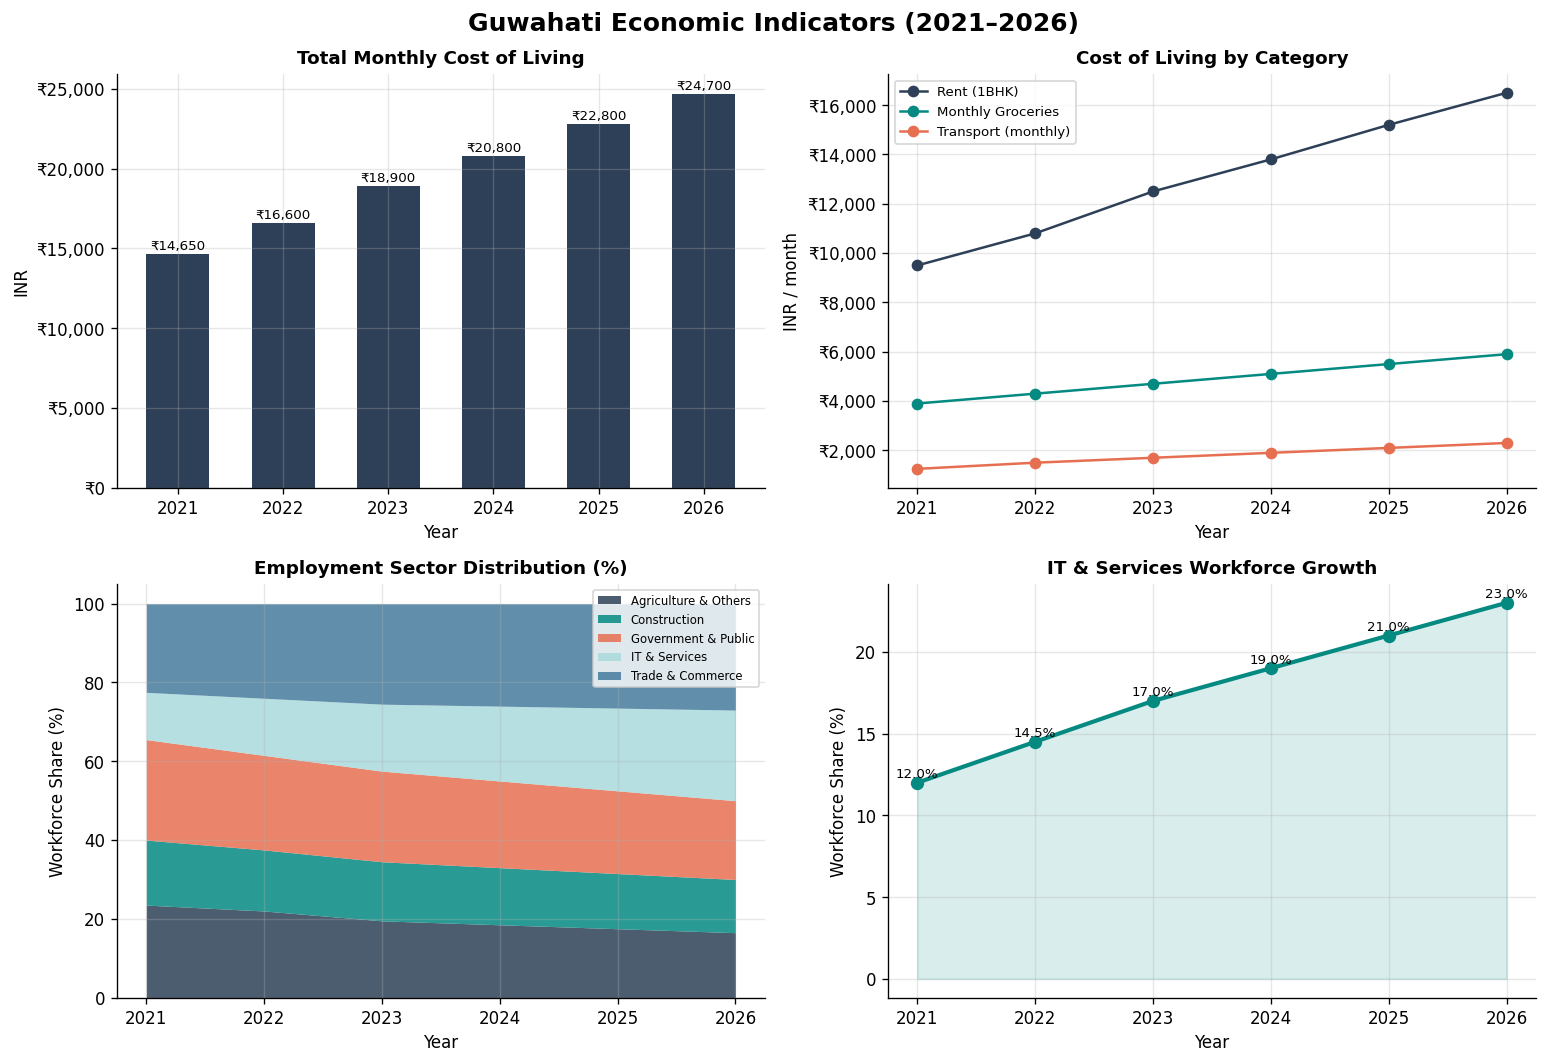

Chart saved!


In [8]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 120,
})

COLORS = ["#2E4057", "#048A81", "#E76F51", "#A8DADC", "#457B9D"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Guwahati Economic Indicators (2021–2026)", fontsize=15, fontweight="bold")

# Plot 1: Total monthly cost
ax = axes[0, 0]
ax.bar(q1["year"], q1["total_monthly_cost"], color=COLORS[0], width=0.6)
ax.set_title("Total Monthly Cost of Living", fontsize=11, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("INR")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x):,}"))
for bar, val in zip(ax.patches, q1["total_monthly_cost"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"₹{int(val):,}", ha="center", va="bottom", fontsize=8)

# Plot 2: Category-wise cost trends
ax = axes[0, 1]
for i, cat in enumerate(["Rent (1BHK)", "Monthly Groceries", "Transport (monthly)"]):
    df_cat = pd.read_sql_query(
        "SELECT year, amount_inr FROM cost_of_living WHERE category=? ORDER BY year",
        conn, params=(cat,))
    ax.plot(df_cat["year"], df_cat["amount_inr"], marker="o", label=cat, color=COLORS[i])
ax.set_title("Cost of Living by Category", fontsize=11, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("INR / month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x):,}"))
ax.legend(fontsize=8)

# Plot 3: Employment sector shares
ax = axes[1, 0]
emp_pivot = pd.read_sql_query(
    "SELECT year, sector, workforce_pct FROM employment ORDER BY year",
    conn).pivot(index="year", columns="sector", values="workforce_pct")
emp_pivot.plot.area(ax=ax, color=COLORS, alpha=0.85, linewidth=0)
ax.set_title("Employment Sector Distribution (%)", fontsize=11, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Workforce Share (%)")
ax.legend(fontsize=7, loc="upper right")

# Plot 4: IT sector growth
ax = axes[1, 1]
ax.plot(q3["year"], q3["it_workforce_pct"], marker="o", color=COLORS[1], linewidth=2.5, markersize=7)
ax.fill_between(q3["year"], q3["it_workforce_pct"], alpha=0.15, color=COLORS[1])
ax.set_title("IT & Services Workforce Growth", fontsize=11, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Workforce Share (%)")
for _, row in q3.iterrows():
    ax.text(row["year"], row["it_workforce_pct"] + 0.3,
            f"{row['it_workforce_pct']}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("guwahati_economic_analysis.png", bbox_inches="tight")
plt.show()
print("Chart saved!")

In [9]:
conn.close()
print("Done.")

Done.
